# UK Retail Operational Intelligence Analysis

## Project Objective

This project analyses transaction data from a UK-based online retailer to identify business inefficiencies and growth opportunities.

The analysis focuses on:
- Revenue concentration by country
- Product revenue and sales volume
- Customer value and purchase frequency
- Seasonal revenue patterns
- Return-related operational inefficiencies

The goal is to use data to support business decisions around market expansion, customer retention, product strategy, and operational improvement.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean chart style
plt.style.use('seaborn-v0_8')

# Load cleaned dataset
df = pd.read_csv('../data/clean_data.csv')

print("Clean dataset loaded successfully ✓")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Clean dataset loaded successfully ✓
Rows: 397,884
Columns: 15


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,MonthName,DayOfWeek,Hour,IsReturn,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010,12,December,Wednesday,8,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,December,Wednesday,8,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010,12,December,Wednesday,8,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,December,Wednesday,8,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,December,Wednesday,8,False,20.34


# 1. Revenue by Geography

This section analyses revenue distribution across countries to identify market concentration risk and international expansion opportunities.

In [2]:
# Group revenue by country
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

# Show top 10 countries
print("TOP 10 COUNTRIES BY REVENUE")
print(country_revenue.head(10))

TOP 10 COUNTRIES BY REVENUE
Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


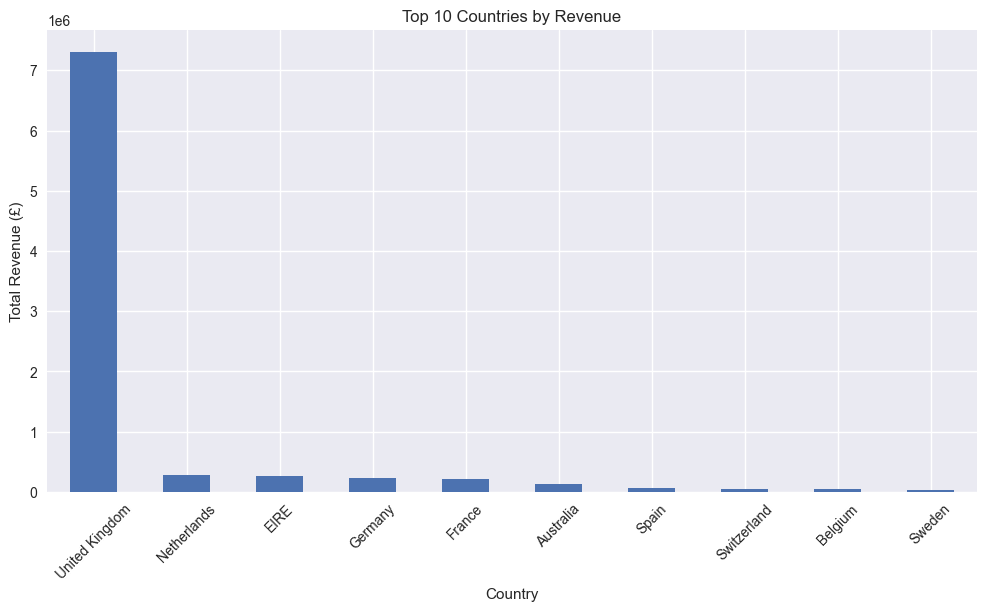

In [3]:
# Group revenue by country and get top 10
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
country_revenue.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)

plt.show()

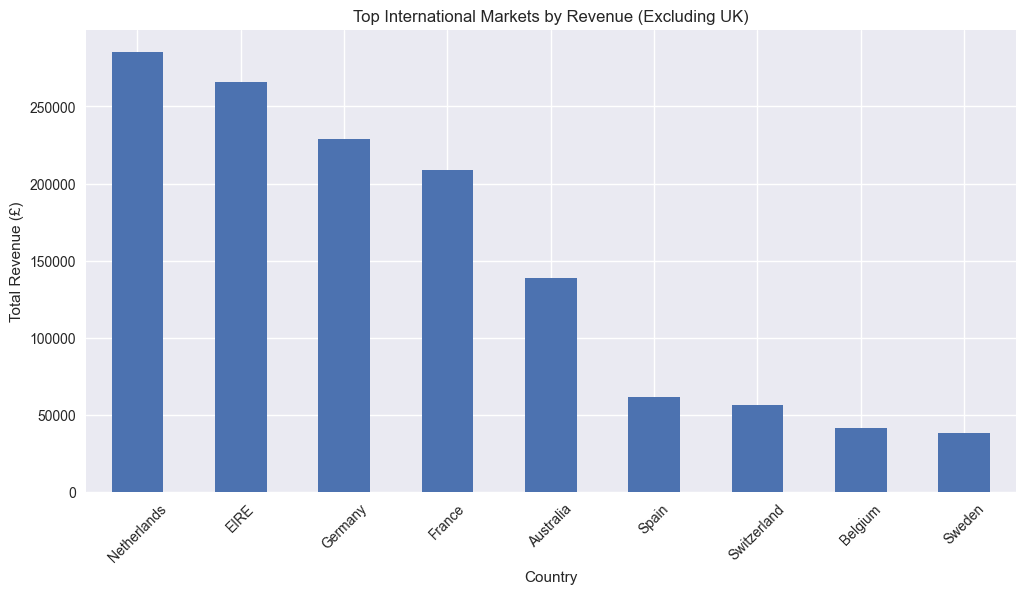

In [4]:
# Countries ranked 2–10 by revenue
country_revenue_no_uk = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)[1:10]

# Plot
plt.figure(figsize=(12,6))
country_revenue_no_uk.plot(kind='bar')

plt.title('Top International Markets by Revenue (Excluding UK)')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)

plt.show()

## Geography Insight

Revenue is heavily concentrated in the UK, indicating strong domestic demand but creating geographic concentration risk.

Secondary European markets such as the Netherlands, Spain, Sweden, and Belgium show potential for expansion and diversification.

### Business Implication:
The company should reduce overdependence on the UK by strategically scaling stronger international markets.

# 2. Product Performance

This section compares top products by revenue and quantity sold to understand which items drive value versus sales volume.

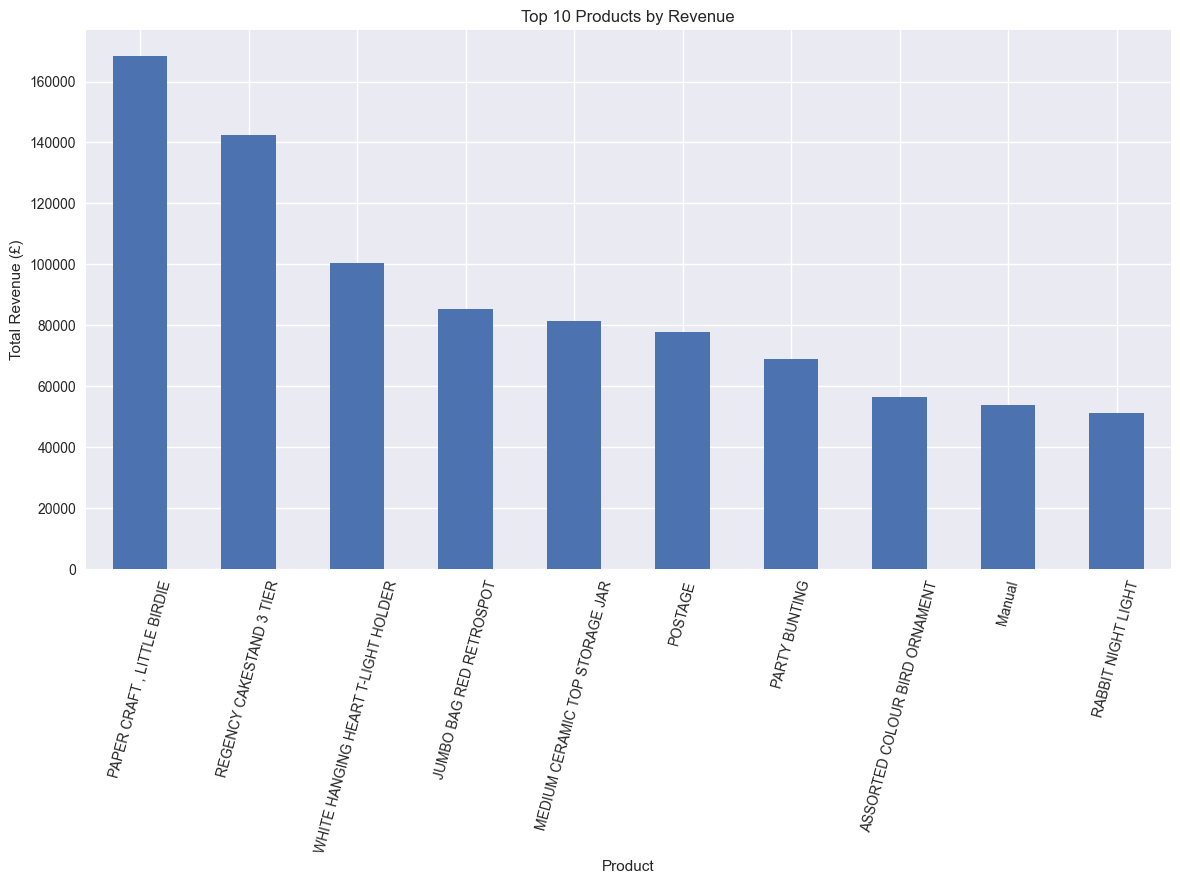

In [5]:
# Top 10 products by revenue
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(14,7))
top_products.plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=75)

plt.show()

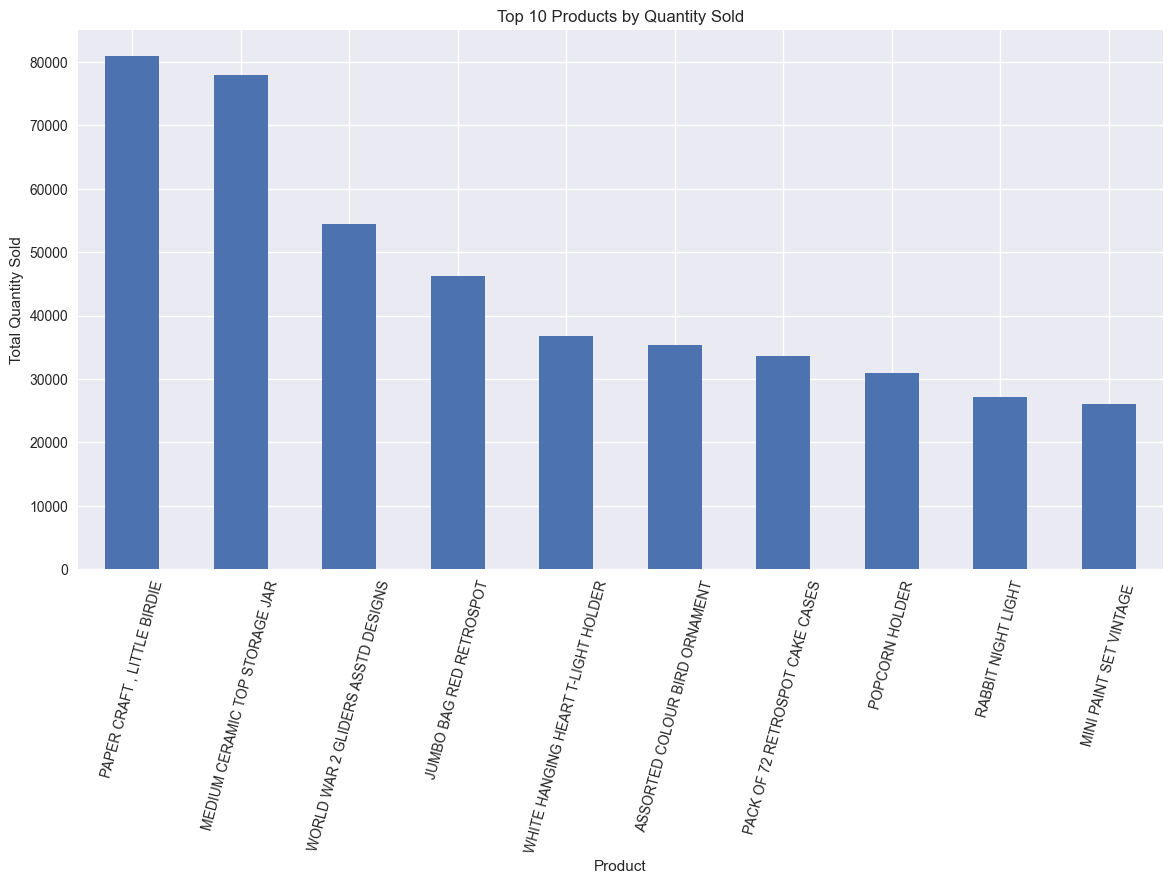

In [6]:
# Top 10 products by quantity sold
top_quantity_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(14,7))
top_quantity_products.plot(kind='bar')

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=75)

plt.show()

## Product Insight

The retailer’s strongest products are concentrated around gifting, party, and decorative categories, suggesting a clear gifting/home décor business model.

Top-selling products by quantity differ from some top revenue products, indicating a mix of volume-driving everyday products and higher-value gifting products.

### Business Implication:
While this category focus supports strong brand identity, it also creates product concentration and seasonal dependency risks. Expanding into broader year-round gifting occasions may improve revenue stability.

# 3. Customer Intelligence

This section identifies high-value customers and frequent purchasers to support retention and upselling strategies.

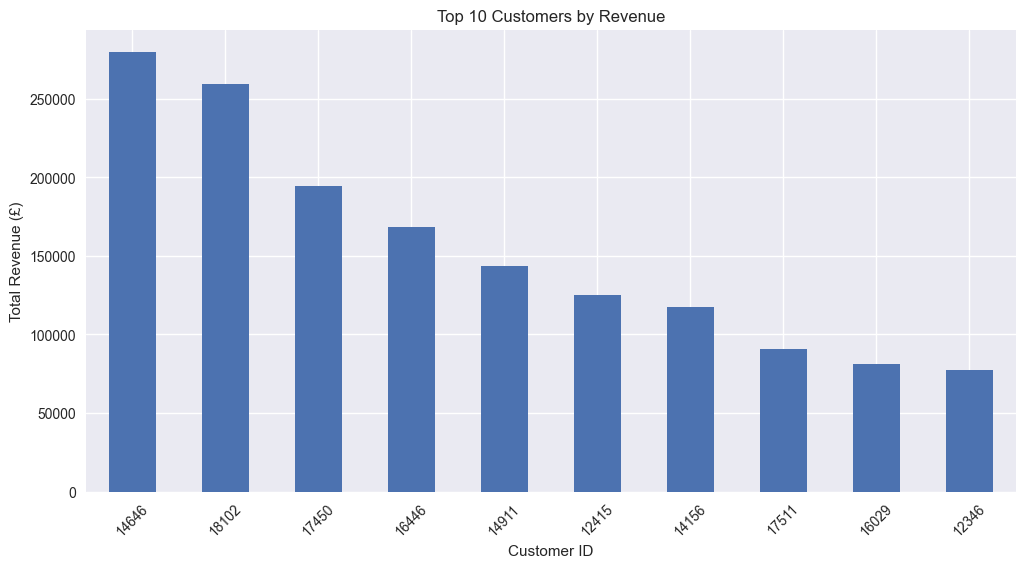

In [7]:
# Top 10 customers by total revenue
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)

plt.show()

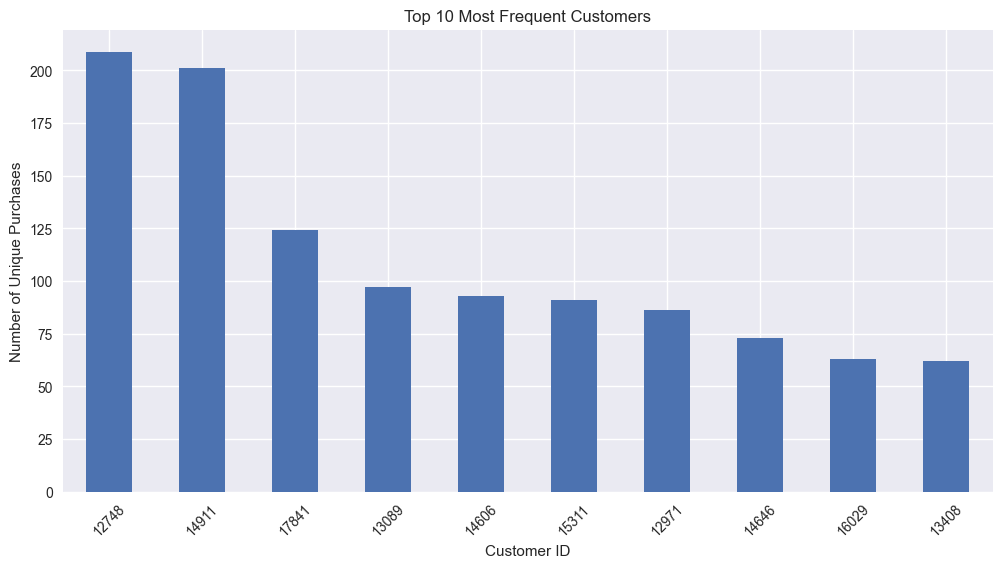

In [8]:
# Top 10 most frequent customers by number of unique purchases
top_frequent_customers = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
top_frequent_customers.plot(kind='bar')

plt.title('Top 10 Most Frequent Customers')
plt.xlabel('Customer ID')
plt.ylabel('Number of Unique Purchases')
plt.xticks(rotation=45)

plt.show()

## Customer Insight

Customer revenue appears relatively distributed, reducing extreme dependence on a handful of buyers.

However, differences between high-revenue customers and high-frequency customers suggest multiple customer segments, including premium spenders and regular lower-value purchasers.

### Business Implication:
The business may benefit from targeted retention strategies for top-value customers while using upselling and loyalty initiatives to increase basket size among frequent purchasers.

# 4. Seasonality Analysis

This section examines monthly revenue trends to identify holiday dependency and off-peak revenue risk.

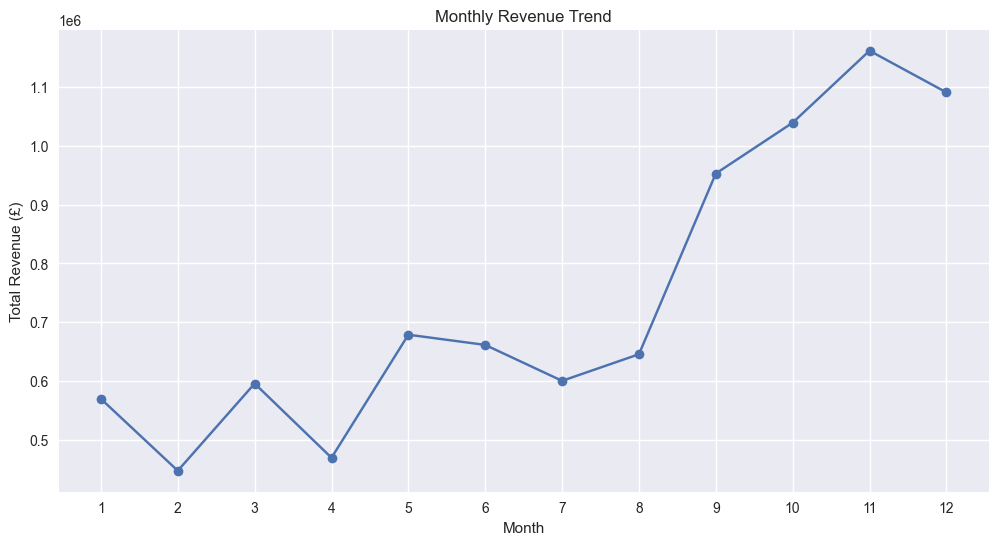

In [9]:
# Monthly revenue trend
monthly_revenue = df.groupby('Month')['Revenue'].sum().sort_index()

# Plot
plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='line', marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(range(1,13))

plt.show()

## Seasonality Insight

Revenue trends show strong seasonal concentration, with November performing significantly better than weaker months such as January.

This suggests the business is heavily influenced by holiday and gifting cycles, creating potential off-season revenue volatility.

### Business Implication:
To reduce seasonal dependency, the retailer should diversify product relevance across year-round gifting occasions and introduce strategies to strengthen off-peak sales performance.

# 5. Returns and Operational Inefficiency

This section analyses returned products to identify potential quality, fulfilment, or expectation-related issues.

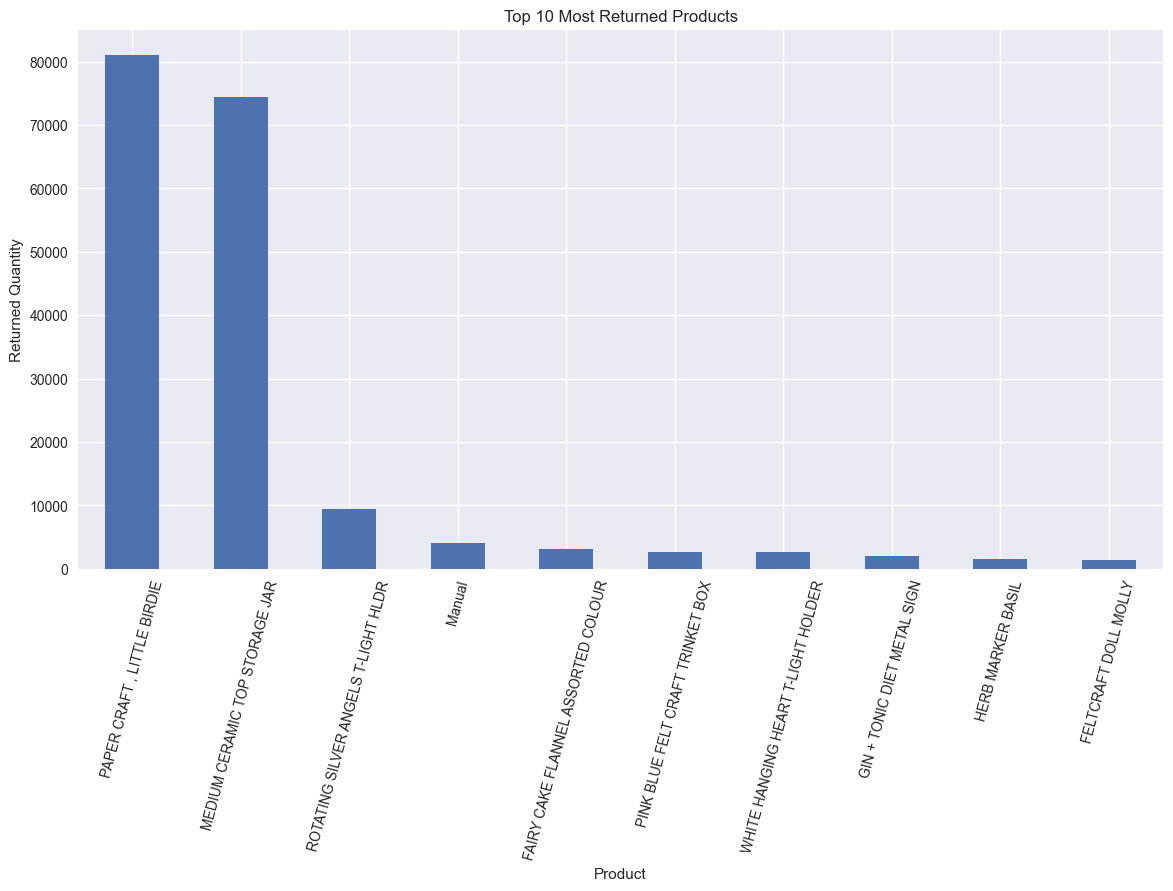

In [10]:
# Load original data to analyse returns
df_returns = pd.read_csv('../data/data.csv', encoding='latin-1')

# Keep only returns (InvoiceNo starts with C)
returns_only = df_returns[df_returns['InvoiceNo'].astype(str).str.startswith('C')].copy()

# Convert return quantities to positive for analysis
returns_only['ReturnQuantity'] = returns_only['Quantity'].abs()

# Top 10 returned products
top_returns = returns_only.groupby('Description')['ReturnQuantity'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(14,7))
top_returns.plot(kind='bar')

plt.title('Top 10 Most Returned Products')
plt.xlabel('Product')
plt.ylabel('Returned Quantity')
plt.xticks(rotation=75)

plt.show()

## Returns Insight

Several top-selling products also appear among the most returned items, suggesting that certain high-demand products may also create disproportionate operational inefficiencies.

This may indicate issues related to product quality, fulfilment, packaging, or customer expectation mismatches.

### Business Implication:
Reducing return rates among high-performing products could significantly improve net profitability by protecting existing revenue while reducing operational leakage.

# Executive Summary

## Key Findings

### 1. UK Market Concentration
The UK generates the majority of company revenue, creating strong domestic performance but exposing the business to geographic concentration risk.

### 2. Seasonal Revenue Dependency
Revenue peaks significantly during holiday-driven months such as November, while weaker months like January suggest vulnerability to seasonal purchasing cycles.

### 3. Product Revenue Leakage
Several top-selling products also experience high return volumes, indicating potential operational inefficiencies related to product quality, fulfilment, or customer expectation gaps.

## Strategic Recommendations

- Expand into stronger international markets to diversify revenue
- Develop year-round gifting strategies to reduce seasonal volatility
- Audit high-selling, high-return products to improve net profitability

# Final Recommendations

## 1. Expand Internationally
Prioritise high-performing secondary markets beyond the UK to reduce geographic concentration risk and diversify revenue streams.

## 2. Build Year-Round Product Strategy
Reduce holiday dependency by expanding into broader gifting occasions and recurring non-seasonal customer needs.

## 3. Reduce Return-Driven Revenue Leakage
Audit top-selling/high-return products to identify and resolve operational inefficiencies related to product quality, logistics, or customer communication.

## Final Strategic Outlook
The retailer demonstrates strong revenue generation but faces concentration risks across geography, seasonality, and product inefficiency. Addressing these areas could improve resilience, profitability, and long-term growth.